# HW1b Structured Analysis Report (Real Artifacts Only)

This notebook reads one structured experiment suite from `experiment.py` outputs and computes all 15 analysis sections using saved artifacts only.


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')

EXPERIMENT_ROOT = "experiments/20260324_033920_hw1b_suite"

if not EXPERIMENT_ROOT:
    raise ValueError("Set EXPERIMENT_ROOT to a concrete suite folder path.")

if not os.path.isdir(EXPERIMENT_ROOT):
    raise FileNotFoundError(f"Experiment root not found: {EXPERIMENT_ROOT}")

summary_csv = os.path.join(EXPERIMENT_ROOT, "summary.csv")
manifest_json = os.path.join(EXPERIMENT_ROOT, "suite_manifest.json")
if not os.path.exists(summary_csv):
    raise FileNotFoundError(f"summary.csv not found under {EXPERIMENT_ROOT}")

summary_df = pd.read_csv(summary_csv)
if os.path.exists(manifest_json):
    with open(manifest_json, "r", encoding="utf-8") as f:
        manifest = json.load(f)
    suite_name = manifest.get('suite', 'unknown')
else:
    manifest = {'suite': 'unknown', 'runs': []}
    suite_name = 'unknown (manifest missing)'

print(f"Loaded suite: {suite_name} | runs: {len(summary_df)}")
summary_df.head()


Loaded suite: hw1b | runs: 7


,run_id,experiment_name,seed,best_epoch,best_val_acc,final_val_acc,overall_accuracy_test,ece,brier,nll,mmacs,mparams,train_wall_time_sec
0,cnn_baseline__seed42,cnn_baseline,42,20,0.7655,0.7655,0.7655,0.011897,0.332667,0.692317,6.276618,0.545098,150.275588
1,kd_custom_mobilenet_student__seed42,kd_custom_mobilenet_student,42,20,0.8929,0.8929,0.8929,0.078451,0.181892,0.632008,96.160266,2.296922,370.603757
2,kd_standard_cnn_student__seed42,kd_standard_cnn_student,42,18,0.7695,0.7658,0.7695,0.096666,0.338566,0.777339,6.276618,0.545098,167.168148
3,resnet18_option1_resize__seed42,resnet18_option1_resize,42,5,0.9005,0.9005,0.9005,0.023492,0.146130,0.303620,37.245962,8.398858,199.051395
4,resnet18_option2_modify__seed42,resnet18_option2_modify,42,4,0.8630,0.8427,0.8630,0.017467,0.198546,0.414132,557.782026,11.173962,50.727200


In [2]:
def run_dir_from_id(run_id: str) -> str:
    return os.path.join(EXPERIMENT_ROOT, run_id)

def load_json(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_history(run_id: str):
    return load_json(os.path.join(run_dir_from_id(run_id), "history.json"))

def load_metrics(run_id: str):
    return load_json(os.path.join(run_dir_from_id(run_id), "metrics.json"))

def load_complexity(run_id: str):
    return load_json(os.path.join(run_dir_from_id(run_id), "complexity.json"))

def load_predictions(run_id: str):
    return np.load(os.path.join(run_dir_from_id(run_id), "predictions_test.npz"))

def load_features(run_id: str):
    p = os.path.join(run_dir_from_id(run_id), "features_test.npz")
    if not os.path.exists(p):
        return None
    return np.load(p)

def split_run_id(run_id: str):
    if "__seed" in run_id:
        exp, seed = run_id.split("__seed")
        return exp, int(seed)
    return run_id, -1

summary_df["experiment_name"] = summary_df["run_id"].apply(lambda r: split_run_id(r)[0])
summary_df["seed"] = summary_df["run_id"].apply(lambda r: split_run_id(r)[1])
summary_df.head()


,run_id,experiment_name,seed,best_epoch,best_val_acc,final_val_acc,overall_accuracy_test,ece,brier,nll,mmacs,mparams,train_wall_time_sec
0,cnn_baseline__seed42,cnn_baseline,42,20,0.7655,0.7655,0.7655,0.011897,0.332667,0.692317,6.276618,0.545098,150.275588
1,kd_custom_mobilenet_student__seed42,kd_custom_mobilenet_student,42,20,0.8929,0.8929,0.8929,0.078451,0.181892,0.632008,96.160266,2.296922,370.603757
2,kd_standard_cnn_student__seed42,kd_standard_cnn_student,42,18,0.7695,0.7658,0.7695,0.096666,0.338566,0.777339,6.276618,0.545098,167.168148
3,resnet18_option1_resize__seed42,resnet18_option1_resize,42,5,0.9005,0.9005,0.9005,0.023492,0.146130,0.303620,37.245962,8.398858,199.051395
4,resnet18_option2_modify__seed42,resnet18_option2_modify,42,4,0.8630,0.8427,0.8630,0.017467,0.198546,0.414132,557.782026,11.173962,50.727200


### 1. Core Learning Dynamics
Accuracy and loss trajectories per run.


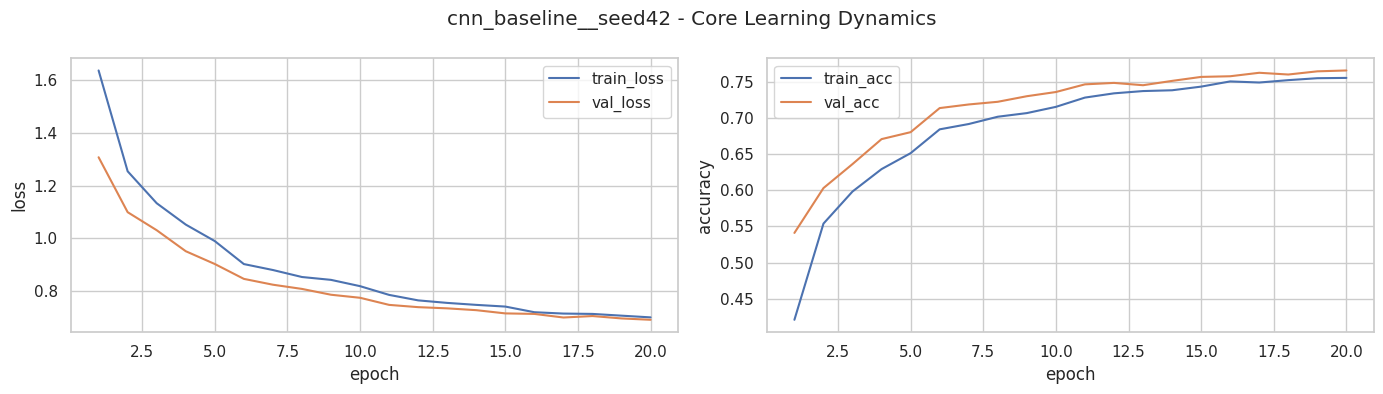

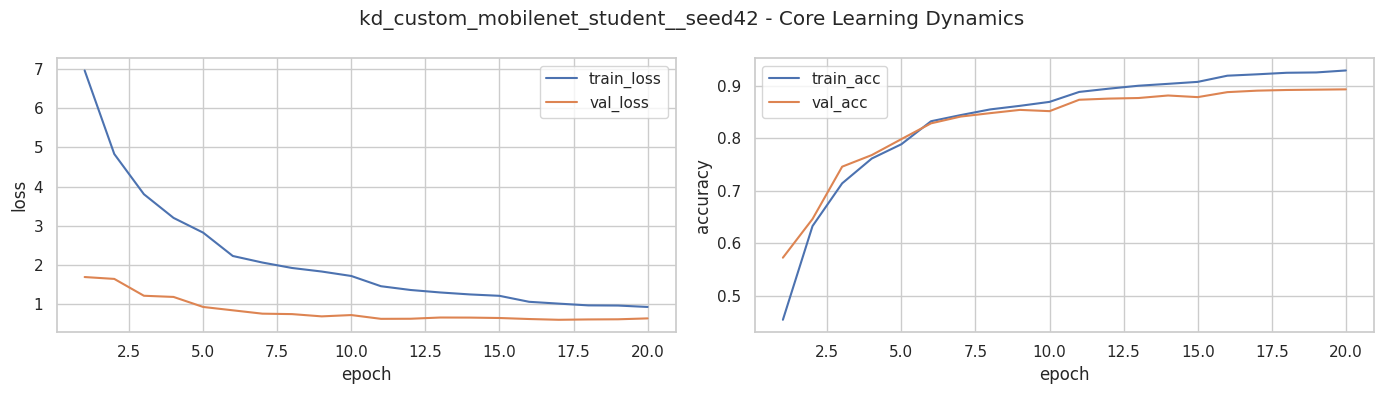

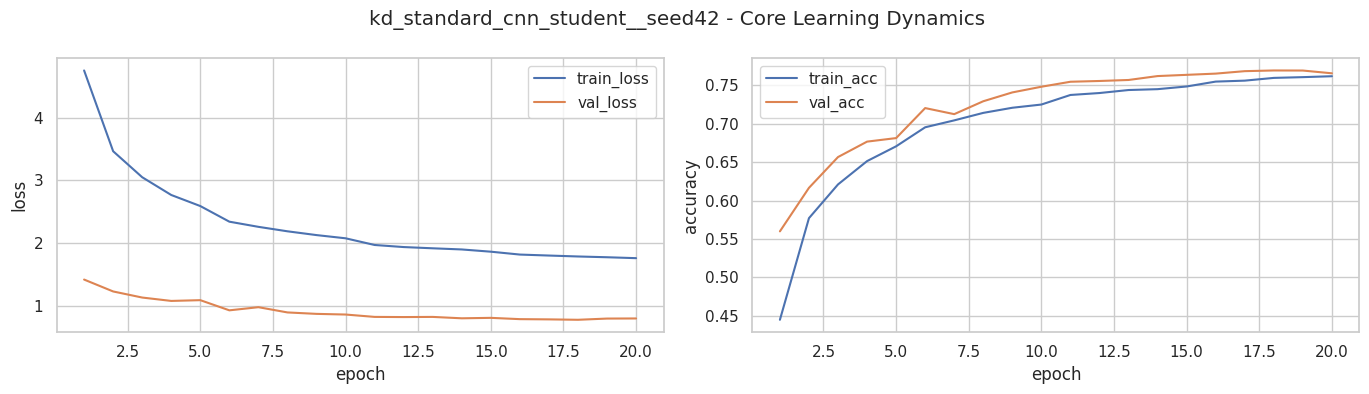

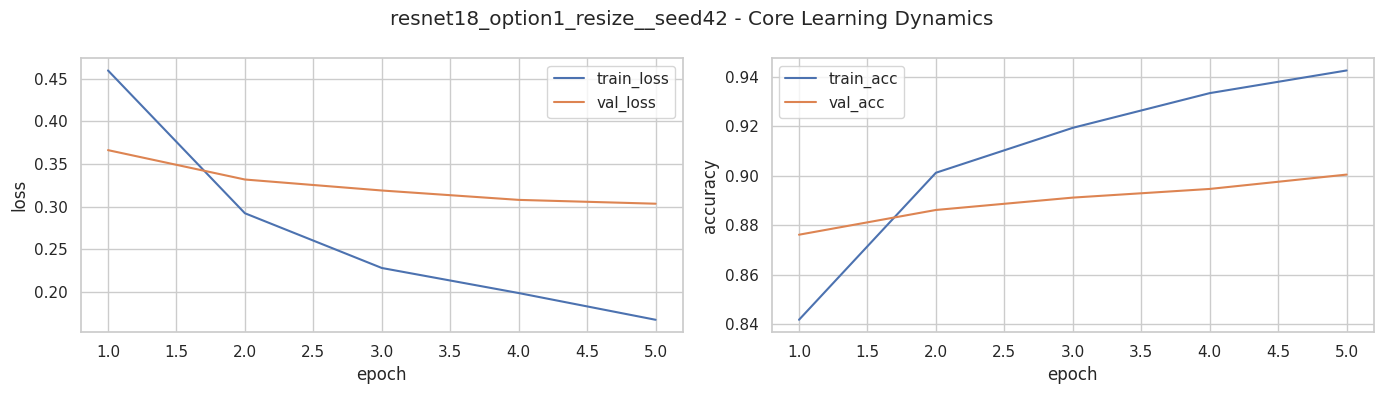

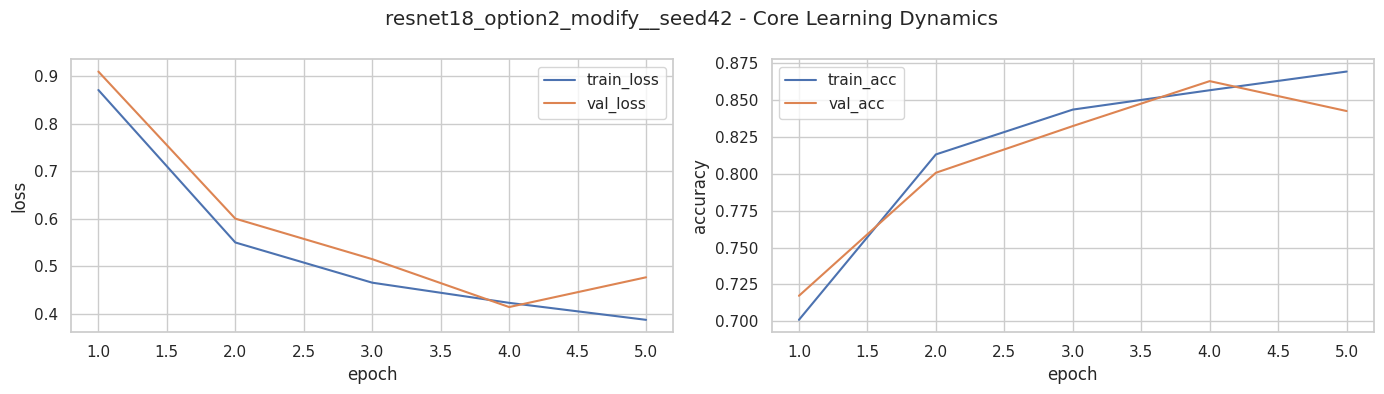

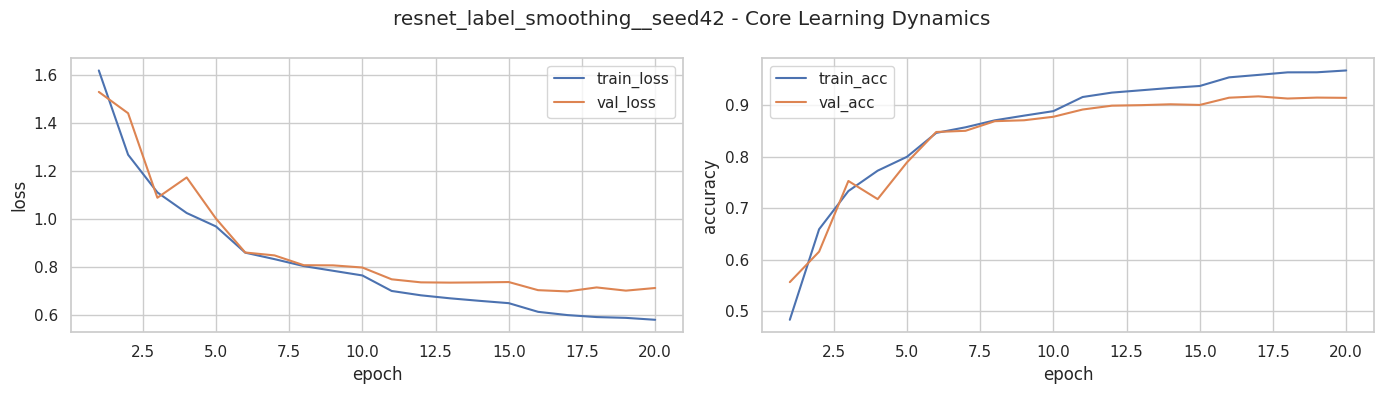

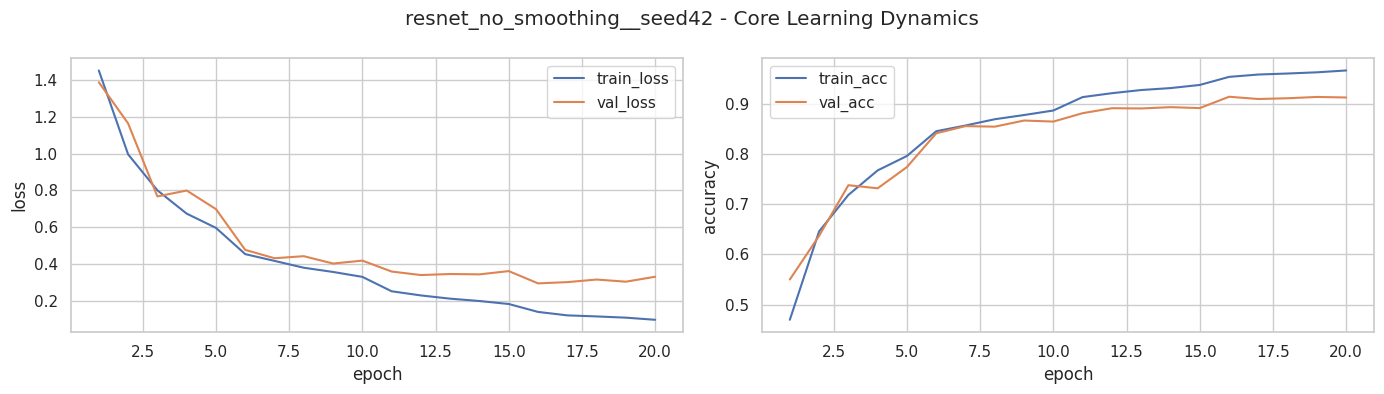

In [3]:
for run_id in summary_df['run_id'].tolist():
    h = load_history(run_id)
    epochs = np.arange(1, len(h['train_loss']) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{run_id} - Core Learning Dynamics")

    ax[0].plot(epochs, h['train_loss'], label='train_loss')
    ax[0].plot(epochs, h['val_loss'], label='val_loss')
    ax[0].set_xlabel('epoch')
    ax[0].set_ylabel('loss')
    ax[0].legend()

    ax[1].plot(epochs, h['train_acc'], label='train_acc')
    ax[1].plot(epochs, h['val_acc'], label='val_acc')
    ax[1].set_xlabel('epoch')
    ax[1].set_ylabel('accuracy')
    ax[1].legend()

    plt.tight_layout()
    plt.show()


### 2. Learning Rate & Optimization
LR schedule vs validation trajectory.


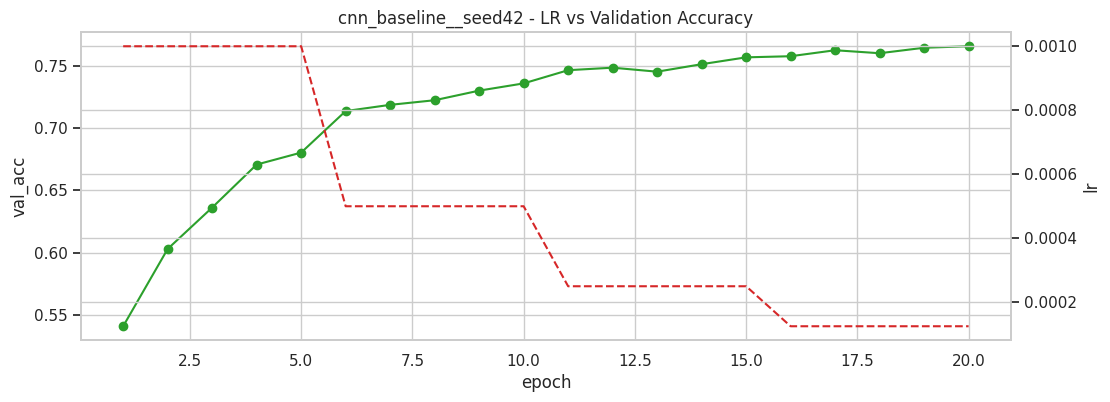

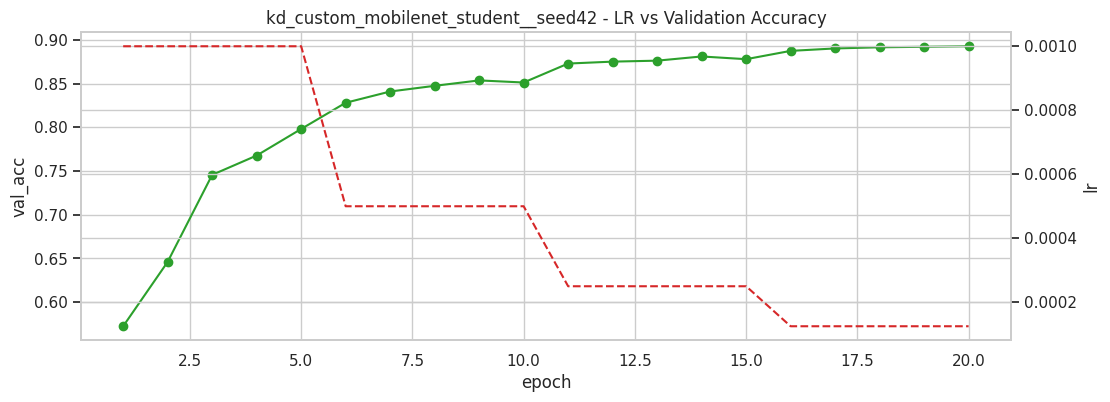

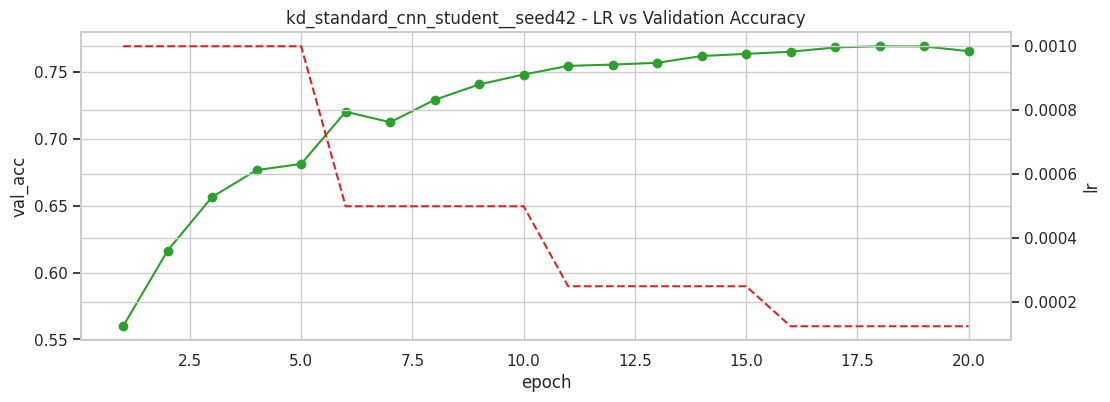

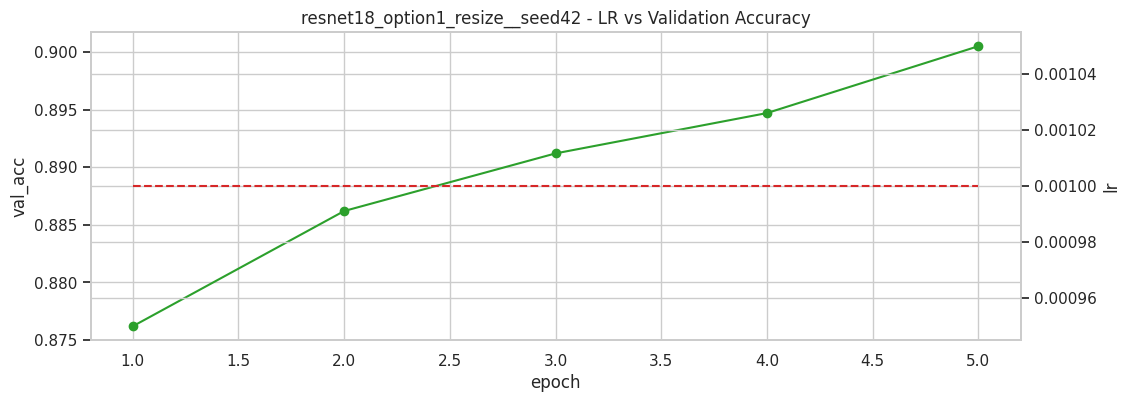

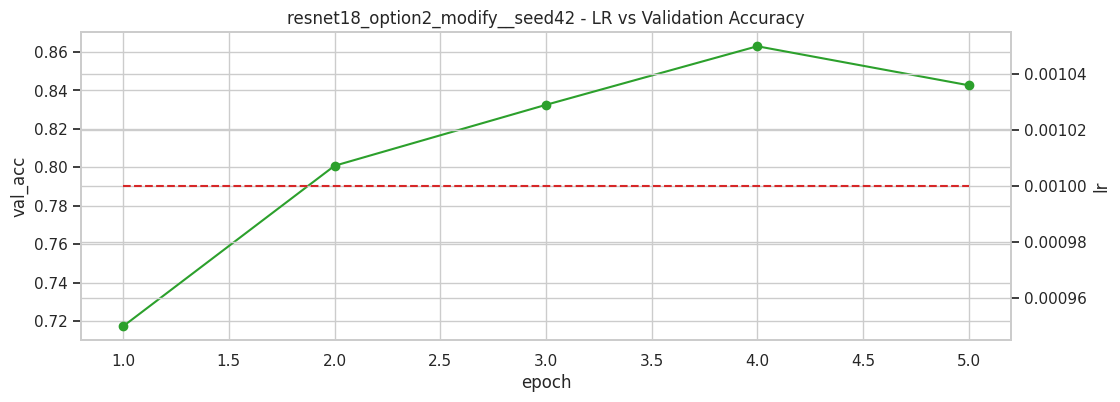

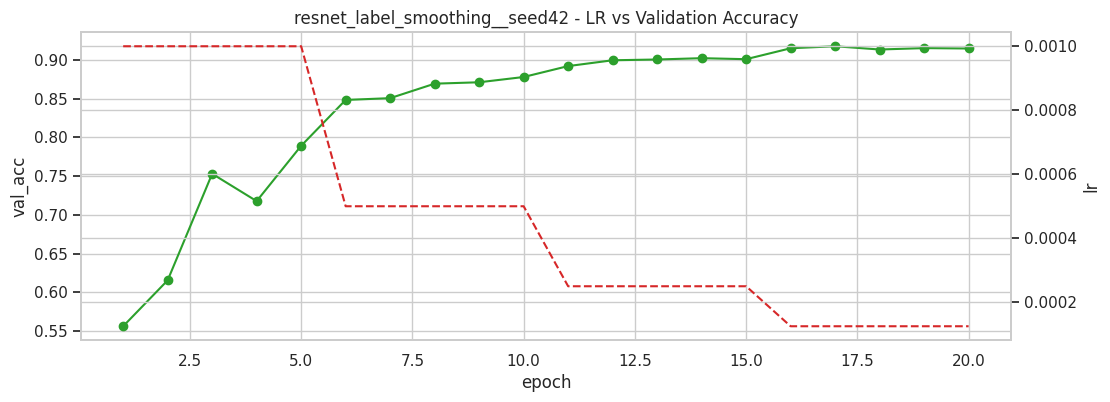

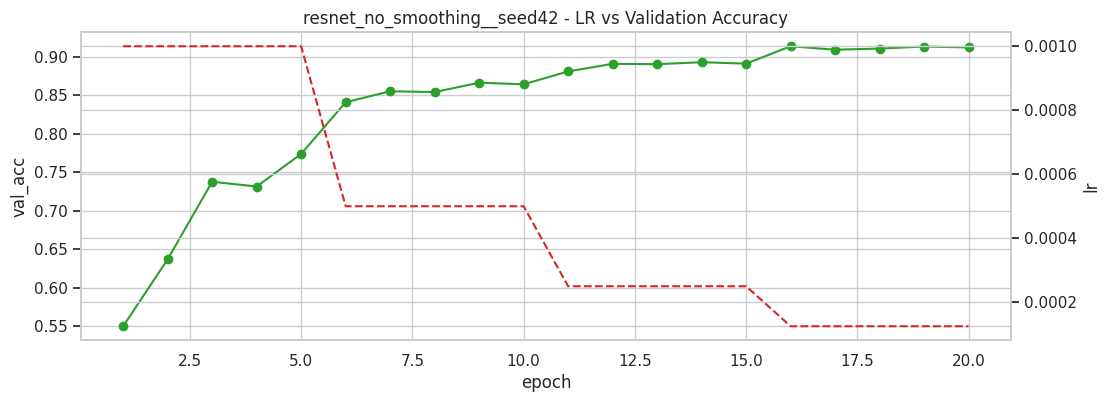

In [4]:
for run_id in summary_df['run_id'].tolist():
    h = load_history(run_id)
    if 'lr' not in h:
        continue
    epochs = np.arange(1, len(h['lr']) + 1)
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax2 = ax1.twinx()

    ax1.plot(epochs, h['val_acc'], color='tab:green', marker='o', label='val_acc')
    ax2.plot(epochs, h['lr'], color='tab:red', linestyle='--', label='lr')

    ax1.set_title(f"{run_id} - LR vs Validation Accuracy")
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('val_acc')
    ax2.set_ylabel('lr')
    plt.show()


### 3. Convergence Speed Thresholds
Epoch to first reach 90% of best validation accuracy.


,run_id,epoch_to_90pct_best,best_val_acc
3,resnet18_option1_resize__seed42,1,0.9005
4,resnet18_option2_modify__seed42,2,0.8630
1,kd_custom_mobilenet_student__seed42,6,0.8929
0,cnn_baseline__seed42,6,0.7655
2,kd_standard_cnn_student__seed42,6,0.7695
5,resnet_label_smoothing__seed42,6,0.9176
6,resnet_no_smoothing__seed42,6,0.9137


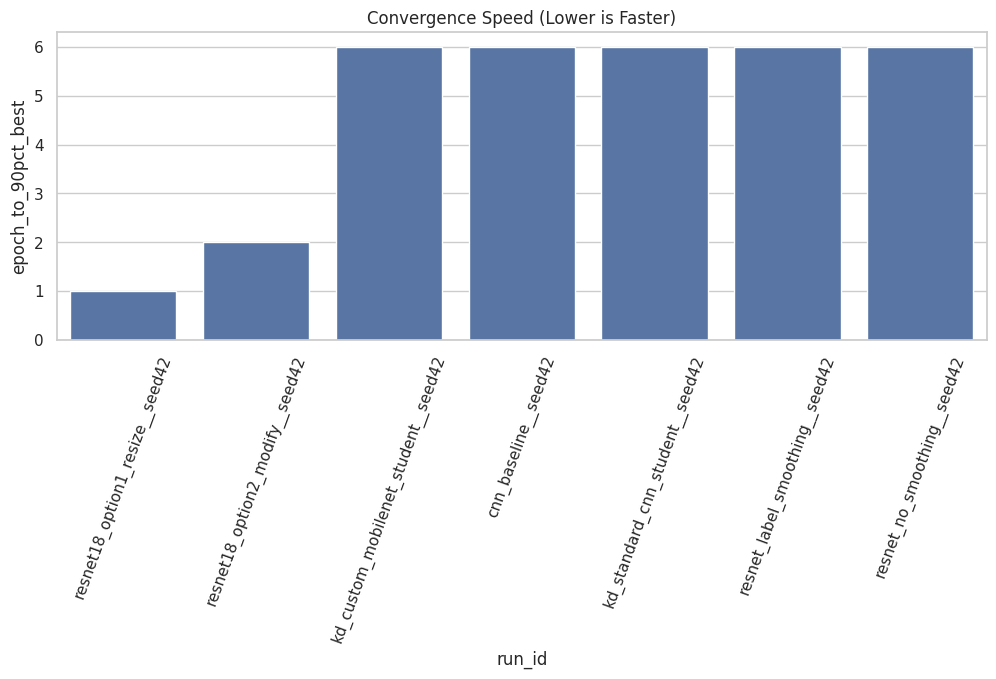

In [5]:
rows = []
for run_id in summary_df['run_id'].tolist():
    h = load_history(run_id)
    vals = h['val_acc']
    best = max(vals)
    th = 0.9 * best
    epoch_90 = next((i + 1 for i, v in enumerate(vals) if v >= th), None)
    rows.append({'run_id': run_id, 'epoch_to_90pct_best': epoch_90, 'best_val_acc': best})

conv_df = pd.DataFrame(rows).sort_values('epoch_to_90pct_best')
display(conv_df)

plt.figure(figsize=(12, 4))
sns.barplot(data=conv_df, x='run_id', y='epoch_to_90pct_best')
plt.xticks(rotation=70)
plt.title('Convergence Speed (Lower is Faster)')
plt.show()


### 4. Pareto Efficiency Frontier
Accuracy vs model complexity (MMACs).


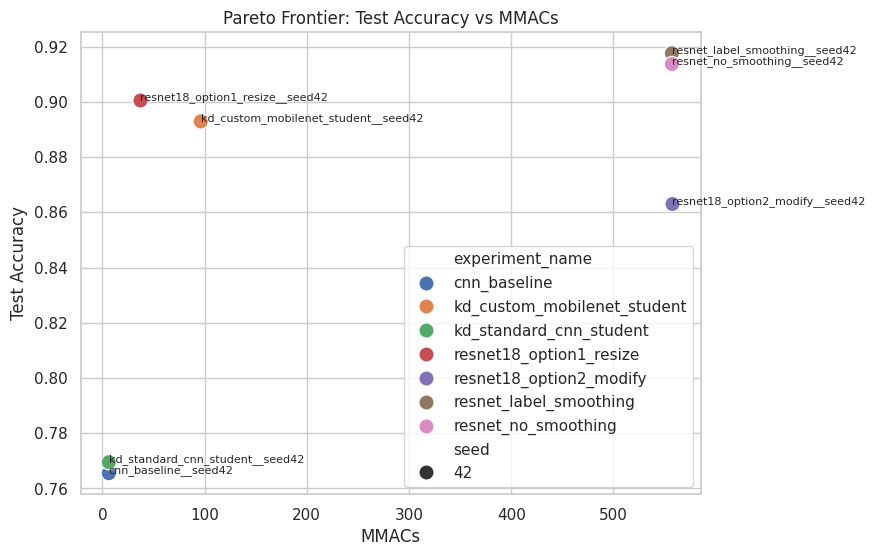

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=summary_df, x='mmacs', y='overall_accuracy_test', hue='experiment_name', style='seed', s=120)
for _, r in summary_df.iterrows():
    plt.text(r['mmacs'], r['overall_accuracy_test'], r['run_id'], fontsize=8)
plt.title('Pareto Frontier: Test Accuracy vs MMACs')
plt.xlabel('MMACs')
plt.ylabel('Test Accuracy')
plt.show()


### 5. Receptive Field vs. Interpolation (Transfer Learning)
Option1 (Resize) vs Option2 (Modify Conv1).


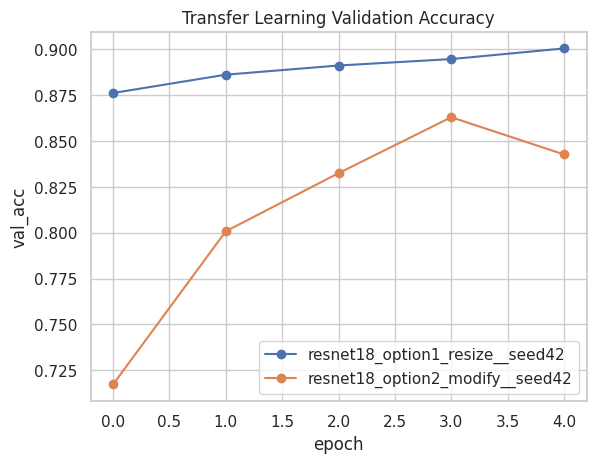

,run_id,best_val_acc,overall_accuracy_test
3,resnet18_option1_resize__seed42,0.9005,0.9005
4,resnet18_option2_modify__seed42,0.8630,0.8630


In [7]:
transfer_runs = summary_df[summary_df['experiment_name'].isin(['resnet18_option1_resize', 'resnet18_option2_modify'])]['run_id'].tolist()
for run_id in transfer_runs:
    h = load_history(run_id)
    plt.plot(h['val_acc'], marker='o', label=run_id)
plt.title('Transfer Learning Validation Accuracy')
plt.xlabel('epoch')
plt.ylabel('val_acc')
plt.legend()
plt.show()

display(summary_df[summary_df['run_id'].isin(transfer_runs)][['run_id', 'best_val_acc', 'overall_accuracy_test']])


### 6. Operation Complexity Breakdown
Standard conv (ResNet/CNN) vs depthwise separable (MobileNet).


,experiment_name,mmacs,mparams,overall_accuracy_test
0,cnn_baseline,6.276618,0.545098,0.7655
2,kd_standard_cnn_student,6.276618,0.545098,0.7695
3,resnet18_option1_resize,37.245962,8.398858,0.9005
1,kd_custom_mobilenet_student,96.160266,2.296922,0.8929
5,resnet_label_smoothing,557.224970,11.173962,0.9176
6,resnet_no_smoothing,557.224970,11.173962,0.9137
4,resnet18_option2_modify,557.782026,11.173962,0.8630


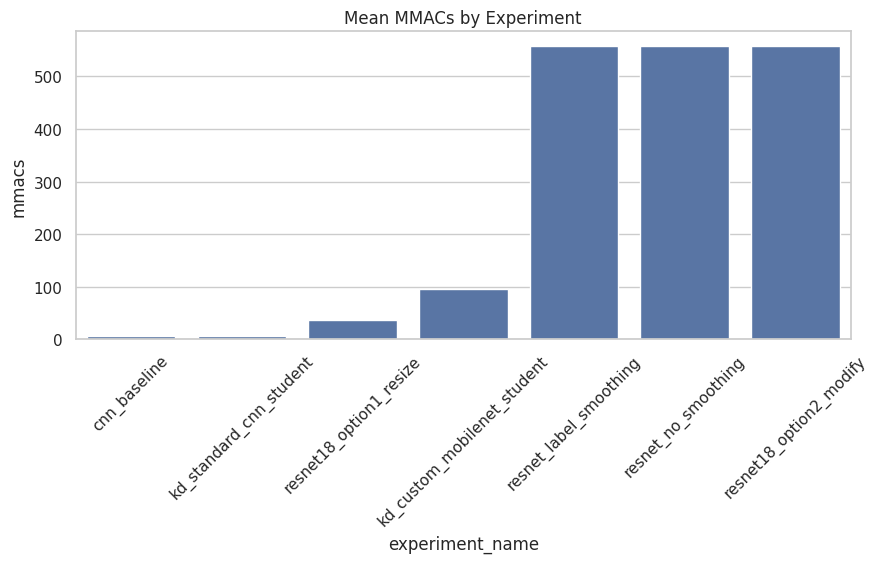

In [8]:
comp = summary_df.groupby('experiment_name', as_index=False)[['mmacs', 'mparams', 'overall_accuracy_test']].mean()
comp = comp.sort_values('mmacs')
display(comp)

plt.figure(figsize=(10, 4))
sns.barplot(data=comp, x='experiment_name', y='mmacs')
plt.xticks(rotation=45)
plt.title('Mean MMACs by Experiment')
plt.show()


### 7. Feature Extraction Separability
Penultimate features projected with PCA->t-SNE.


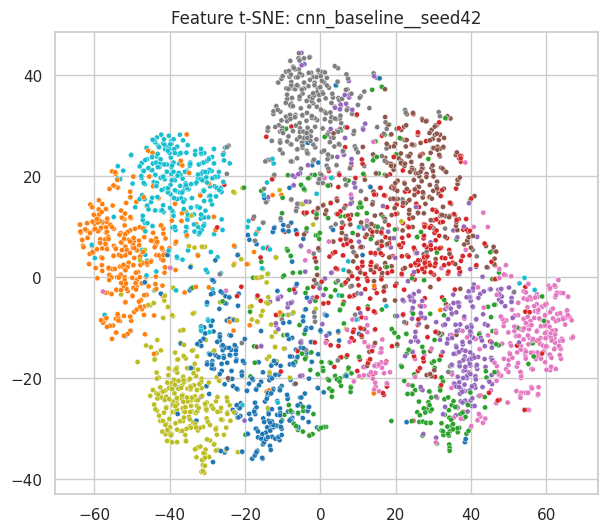

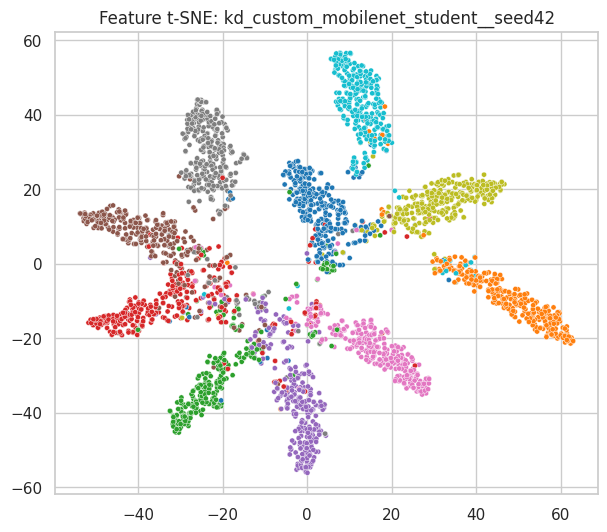

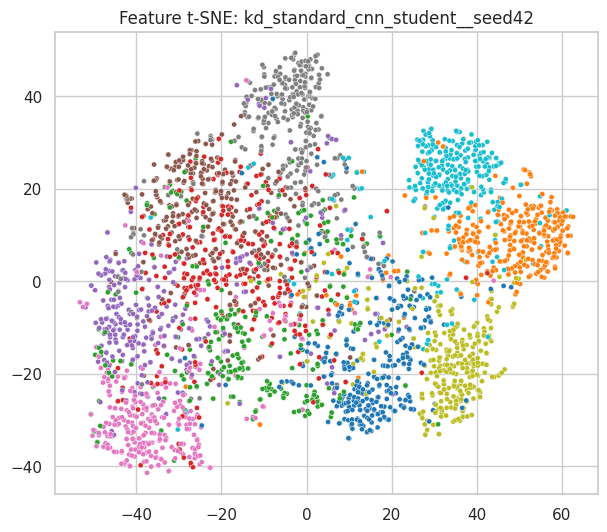

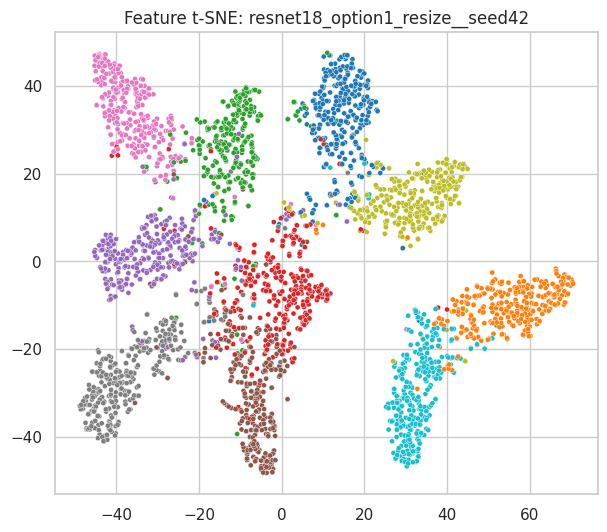

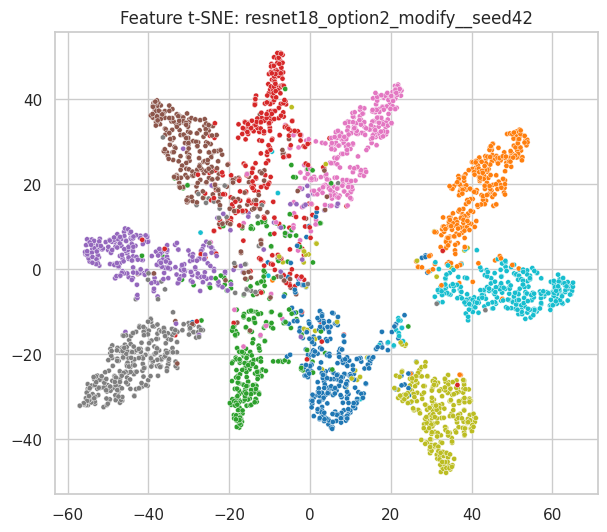

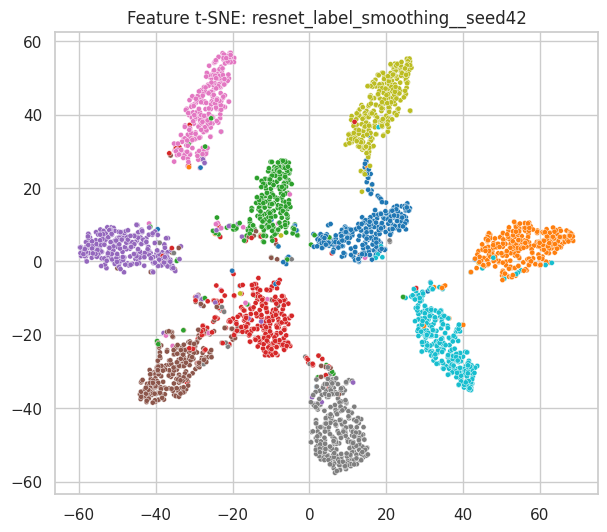

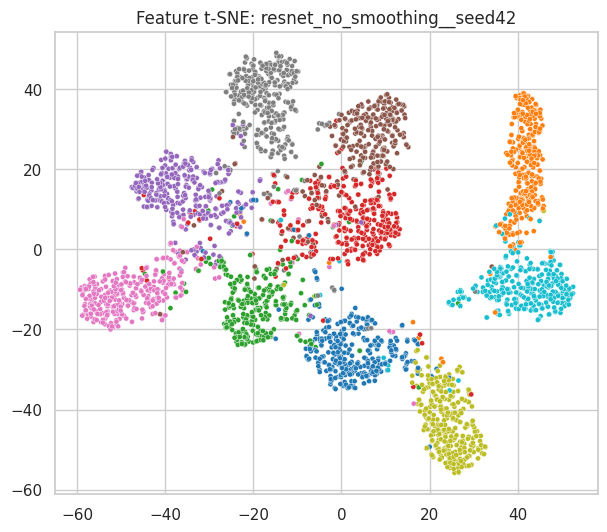

In [9]:
for run_id in summary_df['run_id'].tolist():
    feats = load_features(run_id)
    if feats is None:
        continue
    X = feats['features']
    y = feats['labels']
    if len(X) > 3000:
        idx = np.linspace(0, len(X) - 1, 3000).astype(int)
        X = X[idx]
        y = y[idx]
    pca = PCA(n_components=min(50, X.shape[1]))
    Xr = pca.fit_transform(X)
    z = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(Xr)

    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=z[:,0], y=z[:,1], hue=y, palette='tab10', s=14, legend=False)
    plt.title(f'Feature t-SNE: {run_id}')
    plt.show()


### 8. Teacher Entropy & Sample Difficulty
KD teacher entropy trajectories from saved history.


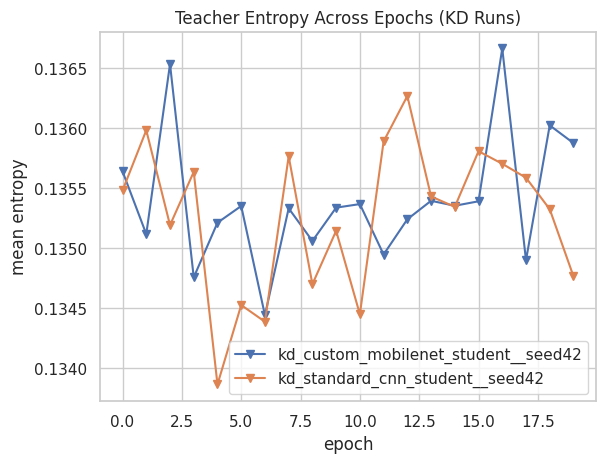

In [10]:
kd_runs = [r for r in summary_df['run_id'].tolist() if 'kd_' in r]
for run_id in kd_runs:
    h = load_history(run_id)
    if 'teacher_entropy' not in h:
        continue
    plt.plot(h['teacher_entropy'], marker='v', label=run_id)
plt.title('Teacher Entropy Across Epochs (KD Runs)')
plt.xlabel('epoch')
plt.ylabel('mean entropy')
plt.legend()
plt.show()


### 9. Knowledge Distillation Alignment
Student-teacher val accuracy gap by seed.


,seed,student,teacher_final_val,student_final_val,gap_teacher_minus_student
0,42,kd_standard_cnn_student,0.9122,0.7658,0.1464
1,42,kd_custom_mobilenet_student,0.9122,0.8929,0.0193


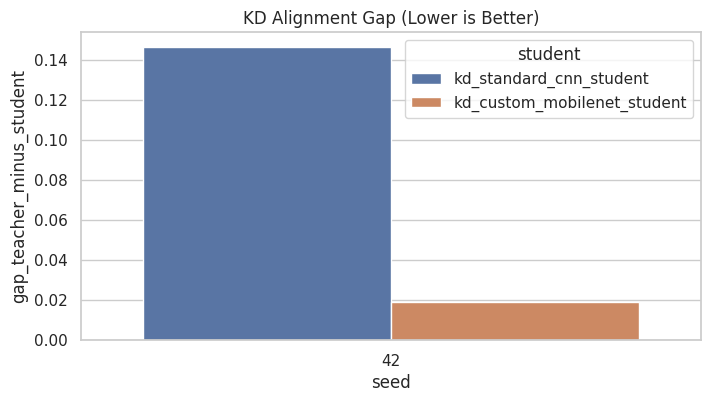

In [11]:
rows = []
for seed in sorted(summary_df['seed'].unique()):
    teacher_row = summary_df[(summary_df['experiment_name'] == 'resnet_no_smoothing') & (summary_df['seed'] == seed)]
    if teacher_row.empty:
        continue
    teacher_final = float(teacher_row['final_val_acc'].iloc[0])
    for student_name in ['kd_standard_cnn_student', 'kd_custom_mobilenet_student']:
        srow = summary_df[(summary_df['experiment_name'] == student_name) & (summary_df['seed'] == seed)]
        if srow.empty:
            continue
        student_final = float(srow['final_val_acc'].iloc[0])
        rows.append({
            'seed': seed,
            'student': student_name,
            'teacher_final_val': teacher_final,
            'student_final_val': student_final,
            'gap_teacher_minus_student': teacher_final - student_final,
        })

align_df = pd.DataFrame(rows)
display(align_df)

if not align_df.empty:
    plt.figure(figsize=(8,4))
    sns.barplot(data=align_df, x='seed', y='gap_teacher_minus_student', hue='student')
    plt.title('KD Alignment Gap (Lower is Better)')
    plt.show()


### 10. Engineering for Reproducibility
Seed-level mean/std stability by experiment.


,experiment_name,mean_test_acc,std_test_acc,n_runs
5,resnet_label_smoothing,0.9176,NaN,1
6,resnet_no_smoothing,0.9137,NaN,1
3,resnet18_option1_resize,0.9005,NaN,1
1,kd_custom_mobilenet_student,0.8929,NaN,1
4,resnet18_option2_modify,0.8630,NaN,1
2,kd_standard_cnn_student,0.7695,NaN,1
0,cnn_baseline,0.7655,NaN,1


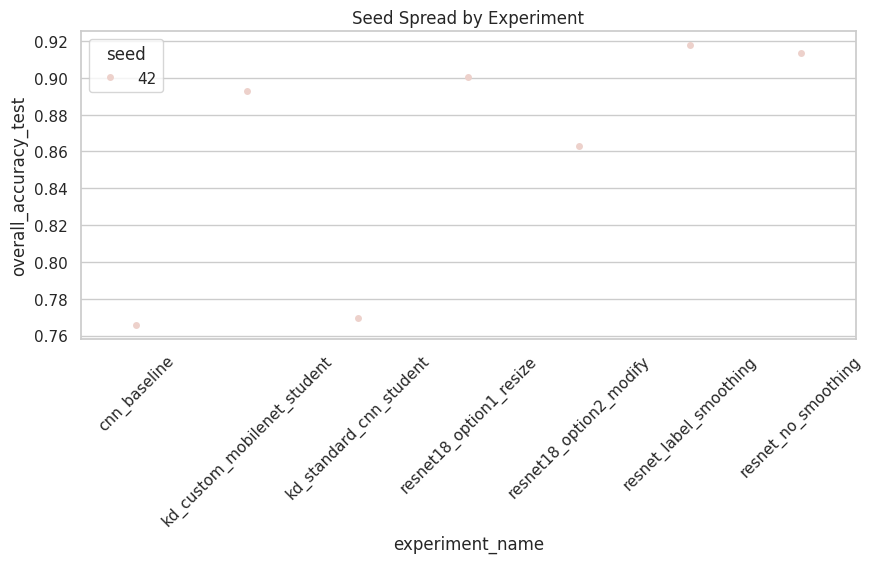

In [12]:
rep = summary_df.groupby('experiment_name', as_index=False).agg(
    mean_test_acc=('overall_accuracy_test', 'mean'),
    std_test_acc=('overall_accuracy_test', 'std'),
    n_runs=('run_id', 'count')
).sort_values('mean_test_acc', ascending=False)
display(rep)

plt.figure(figsize=(10,4))
sns.stripplot(data=summary_df, x='experiment_name', y='overall_accuracy_test', hue='seed', dodge=True)
plt.xticks(rotation=45)
plt.title('Seed Spread by Experiment')
plt.show()


### 11. Model Calibration
ECE, Brier, and NLL from real test probabilities.


,run_id,experiment_name,seed,ece,brier,nll
0,cnn_baseline__seed42,cnn_baseline,42,0.011897,0.332667,0.692317
4,resnet18_option2_modify__seed42,resnet18_option2_modify,42,0.017467,0.198546,0.414132
3,resnet18_option1_resize__seed42,resnet18_option1_resize,42,0.023492,0.146130,0.303620
6,resnet_no_smoothing__seed42,resnet_no_smoothing,42,0.034868,0.133036,0.295218
5,resnet_label_smoothing__seed42,resnet_label_smoothing,42,0.063738,0.127947,0.320901
1,kd_custom_mobilenet_student__seed42,kd_custom_mobilenet_student,42,0.078451,0.181892,0.632008
2,kd_standard_cnn_student__seed42,kd_standard_cnn_student,42,0.096666,0.338566,0.777339


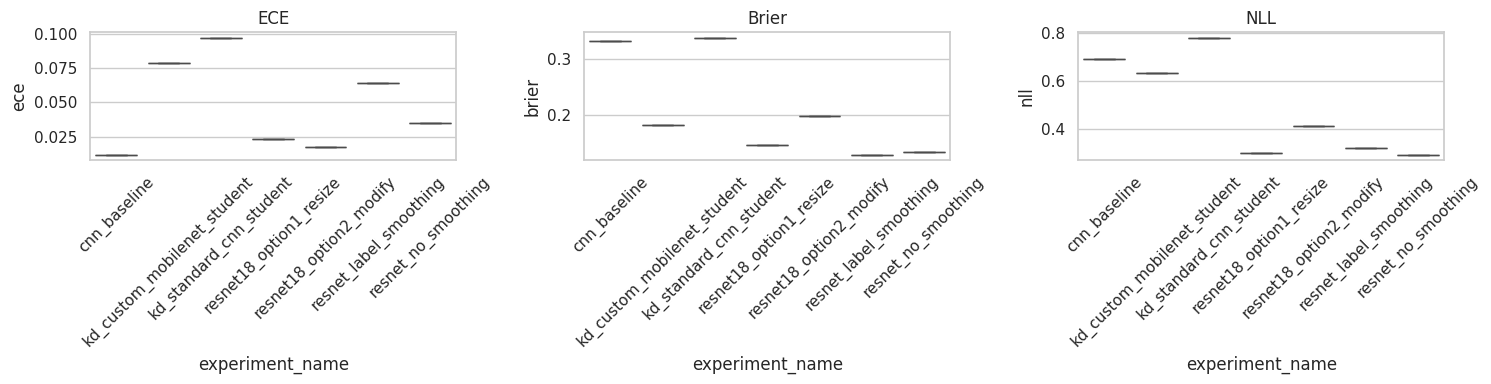

In [13]:
cal = summary_df[['run_id', 'experiment_name', 'seed', 'ece', 'brier', 'nll']].copy()
display(cal.sort_values('ece'))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=cal, x='experiment_name', y='ece', ax=ax[0])
sns.boxplot(data=cal, x='experiment_name', y='brier', ax=ax[1])
sns.boxplot(data=cal, x='experiment_name', y='nll', ax=ax[2])
for a, t in zip(ax, ['ECE', 'Brier', 'NLL']):
    a.set_title(t)
    a.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 12. Inductive Bias & Generalization Gap
Train accuracy minus validation accuracy over epochs.


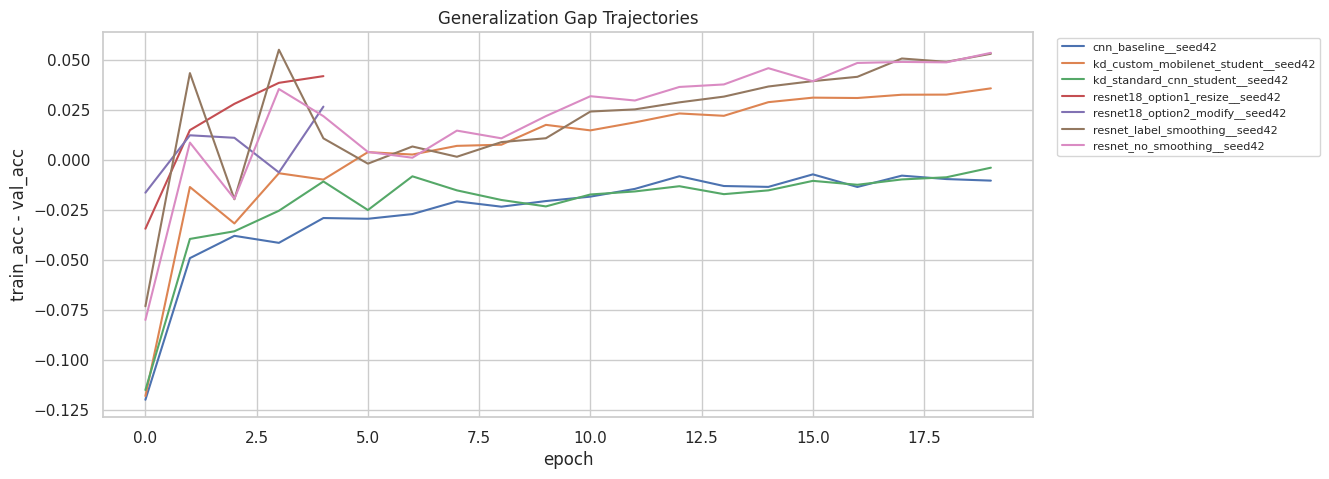

In [14]:
plt.figure(figsize=(12, 5))
for run_id in summary_df['run_id'].tolist():
    h = load_history(run_id)
    gap = np.array(h['train_acc']) - np.array(h['val_acc'])
    plt.plot(gap, label=run_id)
plt.title('Generalization Gap Trajectories')
plt.xlabel('epoch')
plt.ylabel('train_acc - val_acc')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.show()


### 13. Error Diagnostics
Class-wise failure matrix from real test predictions.


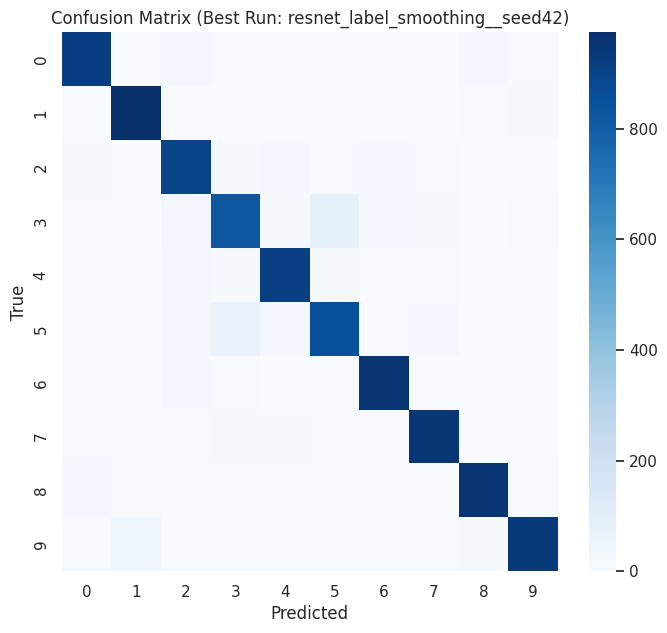

In [15]:
best_run = summary_df.sort_values('overall_accuracy_test', ascending=False).iloc[0]['run_id']
cm = np.load(os.path.join(run_dir_from_id(best_run), 'confusion_matrix_test.npy'))

plt.figure(figsize=(8, 7))
sns.heatmap(cm, cmap='Blues')
plt.title(f'Confusion Matrix (Best Run: {best_run})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


### 14. Latent Representation Visualization
Cross-model latent alignment via PCA->t-SNE.


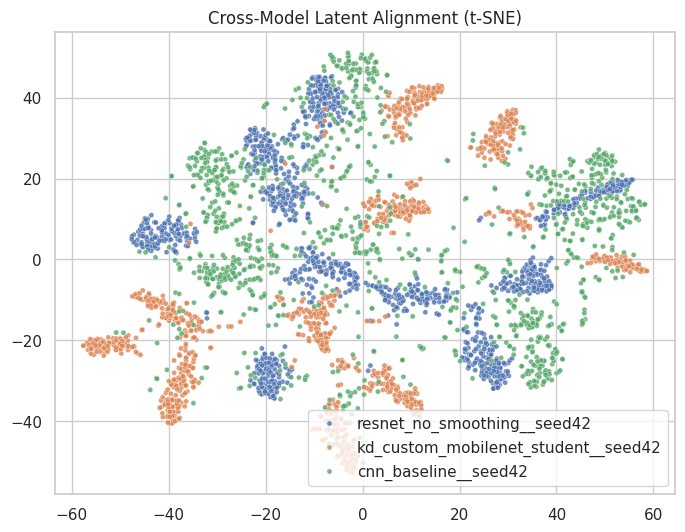

In [16]:
pick_exps = ['resnet_no_smoothing', 'kd_custom_mobilenet_student', 'cnn_baseline']
frames = []
for exp in pick_exps:
    subset = summary_df[summary_df['experiment_name'] == exp]
    if subset.empty:
        continue
    run_id = subset.sort_values('overall_accuracy_test', ascending=False).iloc[0]['run_id']
    feats = load_features(run_id)
    if feats is None:
        continue
    X = feats['features']
    y = feats['labels']
    n = min(1200, len(X))
    idx = np.linspace(0, len(X)-1, n).astype(int)
    frames.append((run_id, X[idx], y[idx]))

if frames:
    # Different models expose different penultimate feature widths (e.g., 512 vs 1280).
    # Align each model to a shared latent width before concatenation.
    target_dim = min(50, min(f[1].shape[1] for f in frames))

    X_blocks = []
    tags = []
    for run_id, X, _ in frames:
        if X.shape[1] > target_dim:
            X_aligned = PCA(n_components=target_dim, random_state=42).fit_transform(X)
        else:
            X_aligned = X
        X_blocks.append(X_aligned)
        tags.extend([run_id] * len(X_aligned))

    X_all = np.concatenate(X_blocks, axis=0)
    model_tag = np.array(tags)

    z = TSNE(n_components=2, perplexity=35, random_state=42, init='pca').fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=z[:,0], y=z[:,1], hue=model_tag, s=14, alpha=0.8)
    plt.title('Cross-Model Latent Alignment (t-SNE)')
    plt.show()
else:
    print('No feature artifacts found for selected experiments.')


### 15. Cost-Effectiveness Table
Normalized test accuracy per MMAC.


In [17]:
eff = summary_df.copy()
eff['acc_per_mmac'] = eff['overall_accuracy_test'] / eff['mmacs']
eff = eff.sort_values('acc_per_mmac', ascending=False)
display(eff[['run_id', 'experiment_name', 'seed', 'overall_accuracy_test', 'mmacs', 'acc_per_mmac']])

best = eff.iloc[0]
print(f"Best cost-effectiveness run: {best['run_id']} | acc_per_mmac={best['acc_per_mmac']:.6f}")


,run_id,experiment_name,seed,overall_accuracy_test,mmacs,acc_per_mmac
2,kd_standard_cnn_student__seed42,kd_standard_cnn_student,42,0.7695,6.276618,0.122598
0,cnn_baseline__seed42,cnn_baseline,42,0.7655,6.276618,0.121961
3,resnet18_option1_resize__seed42,resnet18_option1_resize,42,0.9005,37.245962,0.024177
1,kd_custom_mobilenet_student__seed42,kd_custom_mobilenet_student,42,0.8929,96.160266,0.009286
5,resnet_label_smoothing__seed42,resnet_label_smoothing,42,0.9176,557.224970,0.001647
6,resnet_no_smoothing__seed42,resnet_no_smoothing,42,0.9137,557.224970,0.001640
4,resnet18_option2_modify__seed42,resnet18_option2_modify,42,0.8630,557.782026,0.001547


Best cost-effectiveness run: kd_standard_cnn_student__seed42 | acc_per_mmac=0.122598


### 16. ptflops Complexity Analysis
Detailed complexity view from saved `complexity.json` artifacts (computed via `ptflops.get_model_complexity_info`).


                             run_id             experiment_name      MMACs   MParams        MACs     Params
               cnn_baseline__seed42                cnn_baseline   6.276618  0.545098   6276618.0   545098.0
    kd_standard_cnn_student__seed42     kd_standard_cnn_student   6.276618  0.545098   6276618.0   545098.0
    resnet18_option1_resize__seed42     resnet18_option1_resize  37.245962  8.398858  37245962.0  8398858.0
kd_custom_mobilenet_student__seed42 kd_custom_mobilenet_student  96.160266  2.296922  96160266.0  2296922.0
     resnet_label_smoothing__seed42      resnet_label_smoothing 557.224970 11.173962 557224970.0 11173962.0
        resnet_no_smoothing__seed42         resnet_no_smoothing 557.224970 11.173962 557224970.0 11173962.0
    resnet18_option2_modify__seed42     resnet18_option2_modify 557.782026 11.173962 557782026.0 11173962.0


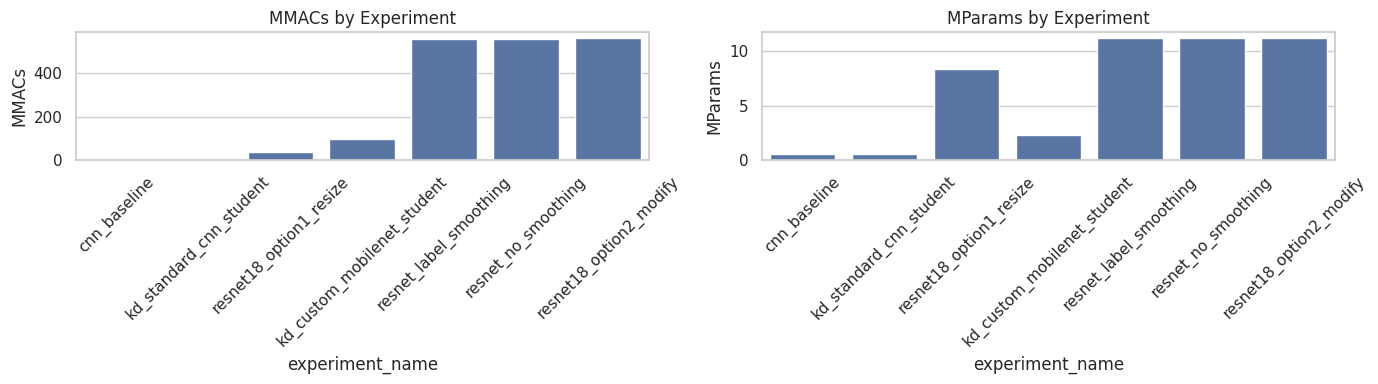

In [18]:
comp_rows = []
for run_id in summary_df['run_id'].tolist():
    c = load_complexity(run_id)
    comp_rows.append({
        'run_id': run_id,
        'experiment_name': run_id.split('__seed')[0],
        'MMACs': c.get('mmacs'),
        'MParams': c.get('mparams'),
        'MACs': c.get('macs'),
        'Params': c.get('params')
    })

comp_df = pd.DataFrame(comp_rows).sort_values('MMACs')
print(comp_df.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=comp_df, x='experiment_name', y='MMACs', ax=ax[0])
sns.barplot(data=comp_df, x='experiment_name', y='MParams', ax=ax[1])
ax[0].set_title('MMACs by Experiment')
ax[1].set_title('MParams by Experiment')
for a in ax:
    a.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 17. Per-Class Precision/Recall/F1 Tables
Loads per-run per-class metrics generated from saved test predictions.


In [19]:
import glob

per_class_files = sorted(glob.glob('reports/hw1b_seed42/per_class_metrics_*.csv'))
if not per_class_files:
    print('No per-class CSV files found. Expected under reports/hw1b_seed42/.')
else:
    print(f'Found {len(per_class_files)} per-class files.')
    for f in per_class_files:
        run_id = os.path.basename(f).replace('per_class_metrics_', '').replace('.csv', '')
        print(f'\n=== {run_id} ===')
        df_pc = pd.read_csv(f)
        print(df_pc.to_string(index=False))


Found 7 per-class files.

=== cnn_baseline__seed42 ===
 class_id class_name  precision  recall       f1  support
        0   airplane   0.775238   0.814 0.794146     1000
        1 automobile   0.875770   0.853 0.864235     1000
        2       bird   0.723606   0.610 0.661964     1000
        3        cat   0.619890   0.561 0.588976     1000
        4       deer   0.743408   0.733 0.738167     1000
        5        dog   0.628814   0.742 0.680734     1000
        6       frog   0.773567   0.837 0.804035     1000
        7      horse   0.829699   0.799 0.814060     1000
        8       ship   0.891005   0.842 0.865810     1000
        9      truck   0.805970   0.864 0.833977     1000

=== kd_custom_mobilenet_student__seed42 ===
 class_id class_name  precision  recall       f1  support
        0   airplane   0.889980   0.906 0.897919     1000
        1 automobile   0.943525   0.969 0.956093     1000
        2       bird   0.845411   0.875 0.859951     1000
        3        cat   0.80364

 class_id class_name  precision  recall       f1  support
        0   airplane   0.923848   0.922 0.922923     1000
        1 automobile   0.955577   0.968 0.961749     1000
        2       bird   0.903967   0.866 0.884576     1000
        3        cat   0.843621   0.820 0.831643     1000
        4       deer   0.857790   0.947 0.900190     1000
        5        dog   0.866190   0.848 0.856998     1000
        6       frog   0.954686   0.927 0.940639     1000
        7      horse   0.933598   0.942 0.937780     1000
        8       ship   0.953815   0.950 0.951904     1000
        9      truck   0.947000   0.947 0.947000     1000


                             run_id  macro_precision  macro_recall  macro_f1  weighted_f1  accuracy             experiment_name
     resnet_label_smoothing__seed42         0.917448        0.9176  0.917409     0.917409    0.9176      resnet_label_smoothing
        resnet_no_smoothing__seed42         0.914009        0.9137  0.913540     0.913540    0.9137         resnet_no_smoothing
    resnet18_option1_resize__seed42         0.900957        0.9005  0.899908     0.899908    0.9005     resnet18_option1_resize
kd_custom_mobilenet_student__seed42         0.892633        0.8929  0.892407     0.892407    0.8929 kd_custom_mobilenet_student
    resnet18_option2_modify__seed42         0.869143        0.8630  0.863366     0.863366    0.8630     resnet18_option2_modify
    kd_standard_cnn_student__seed42         0.768280        0.7695  0.767858     0.767858    0.7695     kd_standard_cnn_student
               cnn_baseline__seed42         0.766697        0.7655  0.764610     0.764610    0.7655     

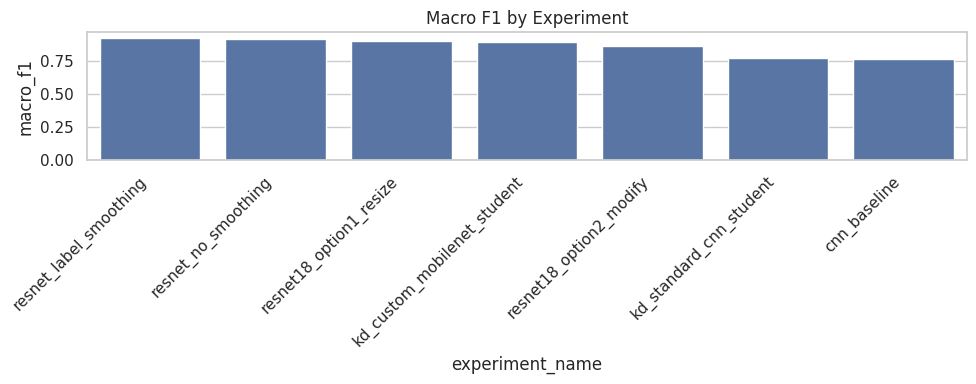

In [20]:
macro_path = 'reports/hw1b_seed42/per_class_macro_summary.csv'
if not os.path.exists(macro_path):
    print('Macro summary CSV not found:', macro_path)
else:
    macro_df = pd.read_csv(macro_path).sort_values('macro_f1', ascending=False)
    macro_df['experiment_name'] = macro_df['run_id'].str.split('__seed').str[0]
    print(macro_df.to_string(index=False))

    plt.figure(figsize=(10,4))
    sns.barplot(data=macro_df, x='experiment_name', y='macro_f1')
    plt.title('Macro F1 by Experiment')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
